In [61]:
import jax
import jax.numpy as jnp
import jax.random as jr

import optax

import matplotlib.pyplot as plt

from ott.geometry import costs
from ott.geometry import semidiscrete_pointcloud as sdpc
from ott.problems.linear import semidiscrete_linear_problem as sdlp
from ott.solvers import linear
from ott.solvers.linear import semidiscrete
from ott.tools import plot

In [ ]:
rng = jr.key(0)
rng_data, rng_solve, rng_sample_geom, rng_sample_out = jr.split(rng, 4)

N_samples = 1200
xs = jax.random.normal(rng, (N_samples, 2))
# Target (Dirac) locations and weights
m, d = 5, 2
# y = jnp.array([
#     [0.0, 2.5],
#     [3.0, 0.5],
#     [1.5, 2.5],
# ], dtype=jnp.float32)
# b = jnp.array([0.3, 0.4, 0.3], dtype=jnp.float32)

#give another target with 6 points that are not symmetric to test the algorithm better
# y = jnp.array([
#     [0.0, 2.5],
#     [3.0, 0.5],
#     [1.5, 2.5],
#     [2.0, 1.0],
#     [0.5, 0.5],
#     [2.5, -1.5],
# ], dtype=jnp.float32)
# b = jnp.ones(6) / 6

y = jnp.array([[ 1.2687988,  1.4590356],
 [-1.5689186, -1.2952491],
 [-1.8861902, -1.4922525],
 [-1.134164,  -1.9104266],
 [-0.9053399, -0.7883038]], dtype=jnp.float32)
b = jnp.ones(5) / 5

geom = sdpc.SemidiscretePointCloud(
    sampler=jr.normal, 
    y=y,
    epsilon=0.0,
    cost_fn=costs.SqEuclidean(),
)

/var/folders/03/6gxdl2k550jd8qv3rp544_jw0000gn/T/ipykernel_78519/2479516479.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x[:, 0], x[:, 1],s = 10, label="samples", cmap="tab10")


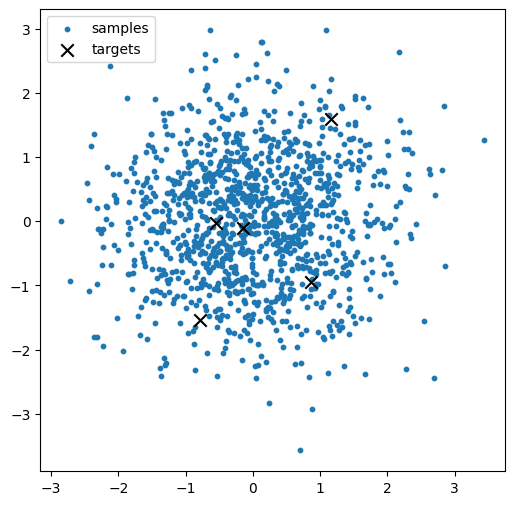

In [63]:
sampled_geom = geom.sample(rng_sample_geom, N_samples)  # sample points


fig, ax = plt.subplots()
# dict_kw = plot.get_plotkwargs(background=False)

fig.set_figheight(6)
fig.set_figwidth(6)


x = sampled_geom.x

ax.scatter(x[:, 0], x[:, 1],s = 10, label="samples", cmap="tab10")
ax.scatter(sampled_geom.y[:, 0], sampled_geom.y[:, 1], c="black", s=80, marker="x", label="targets")
_ = ax.legend()

In [64]:
x

Array([[ 1.2956359 ,  1.3550105 ],
       [-0.40960556, -0.77188545],
       [ 0.38094172,  0.01888919],
       ...,
       [-0.5241552 , -0.9605698 ],
       [-0.8496849 , -1.3082712 ],
       [-0.34286886,  1.926945  ]], dtype=float32)

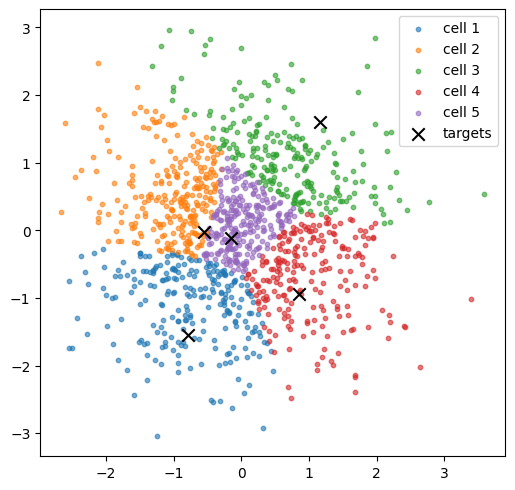

In [65]:
# Solve semi-discrete optimal transport
prob = sdlp.SemidiscreteLinearProblem(geom, b=b)

solver = semidiscrete.SemidiscreteSolver(
    num_iterations=3000,
    batch_size=1024,
    optimizer=optax.adam(learning_rate=0.1),
    error_eval_every=200,
    threshold=1e-3,
)

sd_out = solver(rng_solve, prob)
sampled_out = sd_out.sample(rng_sample_out, N_samples)

# For epsilon=0.0 this is a hard assignment
x = sampled_out.geom.x
assign_ot = sampled_out.paired_indices[1]

fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(6)
for k in range(m):
    mask = assign_ot == k
    ax.scatter(x[mask, 0], x[mask, 1], s=10, alpha=0.6, label=f"cell {k+1}")
ax.scatter(y[:, 0], y[:, 1], c="black", s=80, marker="x", label="targets")
ax.set_aspect("equal", "box")
_ = ax.legend()

In [66]:
# @jax.jit
# def langevin_backward(xs, m, steps=300, dt=0.02):
    
#     # define the action on y0
#     def langevin_backward_single(y0):
#         def step_fn(y, k):
#             s = k / steps
#             denom = 1 - s**2
#             diff = y - s * m
            
#             # calculate weights w
#             w = jnp.exp(-jnp.sum(diff**2, axis=-1) / (2 * denom))
#             w = w / jnp.sum(w)
            
#             # dy and update y
#             dy = jnp.sum(w[:, None] * (m - s * y), axis=0) / denom
#             y_next = y + dt * dy
#             return y_next, None 
        
#         y_final, _ = jax.lax.scan(step_fn, y0, jnp.arange(steps))
#         return y_final

#     batched_langevin = jax.vmap(langevin_backward_single, in_axes=0)
#     ys = batched_langevin(xs)

#     assign_langevin = jnp.argmin(
#         jnp.sum((ys[:, None, :] - m[None, :, :])**2, axis=-1),
#         axis=-1
#     )
    
#     return ys, assign_langevin

# ##usage
# ys, assign_langevin = langevin_backward(x, y)

In [67]:
def langevin_backward_single(y0, m, steps=300):
    ds = 1.0 / steps

    def body(k, y):
        s = k * ds
        denom = jnp.maximum(1e-6, 1.0 - s**2)

        diff = y - s * m
        logits = -jnp.sum(diff**2, axis=1) / (2.0 * denom)
        w = jax.nn.softmax(logits)

        drift = jnp.sum(w[:, None] * (m - s * y), axis=0) / denom
        return y + ds * drift

    return jax.lax.fori_loop(0, steps, body, y0)

langevin_backward = jax.jit(
    jax.vmap(langevin_backward_single, in_axes=(0, None, None)),
    static_argnums=(2,)
)

steps = 300
# x_langevin = sampled_geom.x
ys = langevin_backward(x, y, steps)

assign_langevin = jnp.argmin(
    jnp.sum((ys[:, None, :] - y[None, :, :])**2, axis=2),
    axis=1
)


In [68]:
colors = 1.0*(assign_ot == assign_langevin)

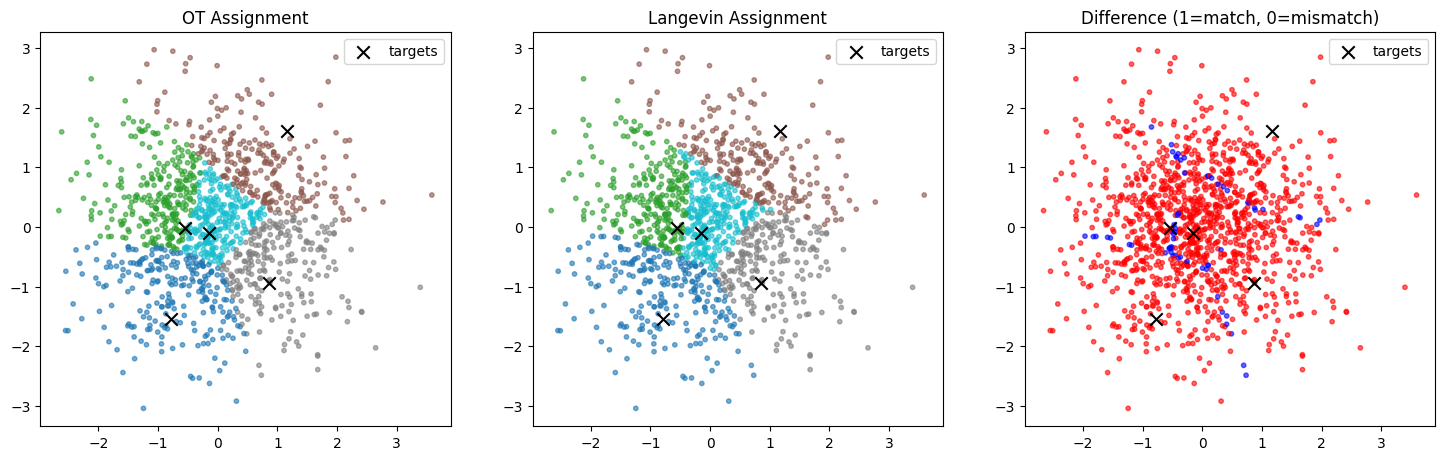

In [69]:
#plot 3 photos, first one is the ot assignment, second one is the langevin assignment, third one is the difference between the two
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
# OT assignment
axs[0].scatter(x[:, 0], x[:, 1], c=assign_ot, s=10, alpha=0.6, cmap="tab10")
axs[0].scatter(y[:, 0], y[:, 1], c="black", s=80, marker="x", label="targets")
axs[0].set_title("OT Assignment")
axs[0].set_aspect("equal", "box")
axs[0].legend()
# Langevin assignment
axs[1].scatter(x[:, 0], x[:, 1], c=assign_langevin, s=10, alpha=0.6, cmap="tab10")
axs[1].scatter(y[:, 0], y[:, 1], c="black", s=80, marker="x", label="targets")
axs[1].set_title("Langevin Assignment")
axs[1].set_aspect("equal", "box")
axs[1].legend()
# Difference
axs[2].scatter(x[:, 0], x[:, 1], c=colors, s=10, alpha=0.6, cmap="bwr")
axs[2].scatter(y[:, 0], y[:, 1], c="black", s=80, marker="x", label="targets")
axs[2].set_title("Difference (1=match, 0=mismatch)")
axs[2].set_aspect("equal", "box")
axs[2].legend()


In [70]:
# Calculate mismatch
mismatch_count = jnp.sum(assign_langevin != assign_ot)
mismatch_pct = (mismatch_count / sampled_geom.x.shape[0]) * 100
print(f"Total points: {sampled_geom.x.shape[0]}")
print(f"Mismatched points: {mismatch_count} ({mismatch_pct:.2f}%)")

Total points: 1200
Mismatched points: 63 (5.25%)


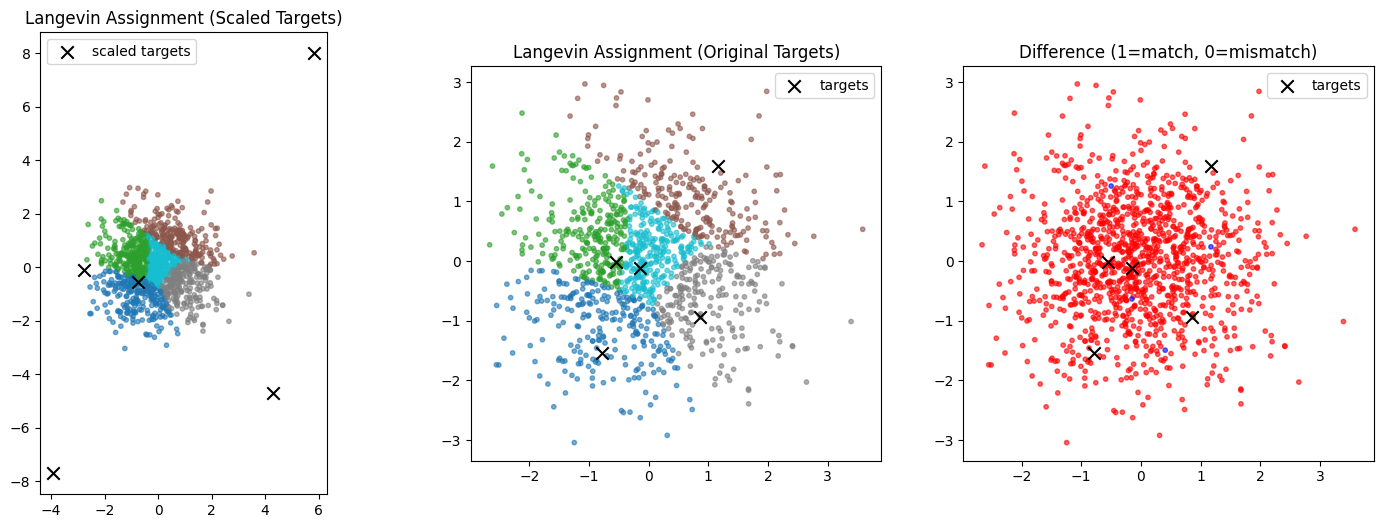

In [71]:
lambda_ = 5
y_scaled = y * (lambda_)
ys_scaled = langevin_backward(x, y_scaled, steps)
assign_langevin_scaled = jnp.argmin(
    jnp.sum((ys_scaled[:, None, :] - y_scaled[None, :, :])**2, axis=2),
    axis=1
)
colors_scaled = 1.0*(assign_ot == assign_langevin_scaled)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
# Langevin assignment with scaled targets
axs[0].scatter(x[:, 0], x[:, 1], c=assign_langevin_scaled, s=10, alpha=0.6, cmap="tab10")
axs[0].scatter(y_scaled[:, 0], y_scaled[:, 1], c="black", s=80, marker="x", label="scaled targets")
axs[0].set_title("Langevin Assignment (Scaled Targets)")
axs[0].set_aspect("equal", "box")
axs[0].legend()
# Langevin assignment (same as before)
axs[1].scatter(x[:, 0], x[:, 1], c=assign_langevin, s=10, alpha=0.6, cmap="tab10")
axs[1].scatter(y[:, 0], y[:, 1], c="black", s=80, marker="x", label="targets")
axs[1].set_title("Langevin Assignment (Original Targets)")
axs[1].set_aspect("equal", "box")
axs[1].legend()
# Difference between scaled and original Langevin assignments
colors_diff = 1.0*(assign_langevin_scaled == assign_langevin)
axs[2].scatter(x[:, 0], x[:, 1], c=colors_diff, s=10, alpha=0.6, cmap="bwr")
axs[2].scatter(y[:, 0], y[:, 1], c="black", s=80, marker="x", label="targets")
axs[2].set_title("Difference (1=match, 0=mismatch)")
axs[2].set_aspect("equal", "box")
axs[2].legend()

In [72]:
#count mismatch between scaled and original Langevin assignments
mismatch_count_scaled = jnp.sum(assign_langevin_scaled != assign_langevin)
mismatch_pct_scaled = (mismatch_count_scaled / sampled_geom.x.shape[0]) * 100
print(f"Total points: {sampled_geom.x.shape[0]}")
print(f"Mismatched points (scaled vs original): {mismatch_count_scaled} ({mismatch_pct_scaled:.2f}%)")

Total points: 1200
Mismatched points (scaled vs original): 4 (0.33%)


In [73]:
lamda = [x for x in jnp.logspace(jnp.log10(0.1), jnp.log10(10.0), 20)]

#comput the langevin assignment for each lambda and count the mismatch with the original OT assignment
for lambda_ in lamda:
    y_scaled = y * (lambda_)
    ys_scaled = langevin_backward(x, y_scaled, steps)
    assign_langevin_scaled = jnp.argmin(
        jnp.sum((ys_scaled[:, None, :] - y_scaled[None, :, :])**2, axis=2),
        axis=1
    )
    mismatch_count_scaled = jnp.sum(assign_langevin_scaled != assign_langevin)
    mismatch_pct_scaled = (mismatch_count_scaled / sampled_geom.x.shape[0]) * 100
    print(f"Lambda: {lambda_}")
    print(f"Mismatched points (scaled vs original): {mismatch_count_scaled} ({mismatch_pct_scaled:.2f}%)")

#plot the mismatch percentage as a function of lambda
mismatch_percentages = []
for lambda_ in lamda:
    y_scaled = y * (lambda_)
    ys_scaled = langevin_backward(x, y_scaled, steps)
    assign_langevin_scaled = jnp.argmin(
        jnp.sum((ys_scaled[:, None, :] - y_scaled[None, :, :])**2, axis=2),
        axis=1
    )
    mismatch_count_scaled = jnp.sum(assign_langevin_scaled != assign_langevin)
    mismatch_pct_scaled = (mismatch_count_scaled / sampled_geom.x.shape[0]) * 100
    mismatch_percentages.append(mismatch_pct_scaled)

Lambda: 0.10000000149011612
Mismatched points (scaled vs original): 35 (2.92%)
Lambda: 0.12742748856544495
Mismatched points (scaled vs original): 20 (1.67%)
Lambda: 0.16237768530845642
Mismatched points (scaled vs original): 12 (1.00%)
Lambda: 0.2069137990474701
Mismatched points (scaled vs original): 7 (0.58%)
Lambda: 0.2636651396751404
Mismatched points (scaled vs original): 5 (0.42%)
Lambda: 0.3359818458557129
Mismatched points (scaled vs original): 4 (0.33%)
Lambda: 0.4281332194805145
Mismatched points (scaled vs original): 3 (0.25%)
Lambda: 0.5455595254898071
Mismatched points (scaled vs original): 2 (0.17%)
Lambda: 0.695192813873291
Mismatched points (scaled vs original): 0 (0.00%)
Lambda: 0.8858667612075806
Mismatched points (scaled vs original): 0 (0.00%)
Lambda: 1.1288379430770874
Mismatched points (scaled vs original): 0 (0.00%)
Lambda: 1.4384498596191406
Mismatched points (scaled vs original): 0 (0.00%)
Lambda: 1.8329806327819824
Mismatched points (scaled vs original): 0 (0

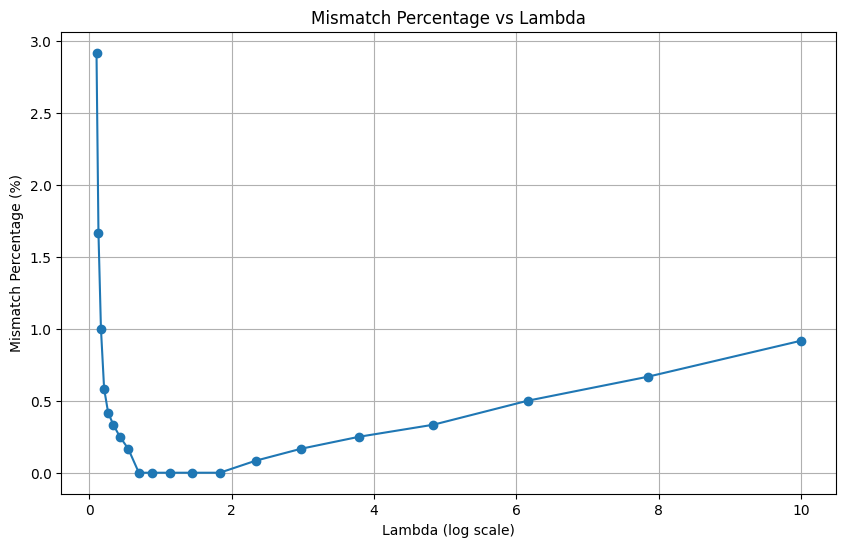

In [74]:
# Plotting the line graph for each lambda and its corresponding mismatch count
plt.figure(figsize=(10, 6))
plt.plot(lamda, mismatch_percentages, marker='o')
# plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Mismatch Percentage (%)')
plt.title('Mismatch Percentage vs Lambda')
plt.grid(True)
plt.show()

In [75]:
#show the range of lambda where the mismatch percentage is low (e.g. < 5%)
for lambda_, mismatch_pct in zip(lamda, mismatch_percentages):
    if mismatch_pct == 0:
        print(f"Lambda: {lambda_}, Mismatch Percentage: {mismatch_pct:.2f}%")    

Lambda: 0.695192813873291, Mismatch Percentage: 0.00%
Lambda: 0.8858667612075806, Mismatch Percentage: 0.00%
Lambda: 1.1288379430770874, Mismatch Percentage: 0.00%
Lambda: 1.4384498596191406, Mismatch Percentage: 0.00%
Lambda: 1.8329806327819824, Mismatch Percentage: 0.00%


In [76]:
#consider 1 target point and 1 source, try to plot the trajectory of the langevin backward for a lambda scaled target to see the trajectory of the samples and how they converge to the target point


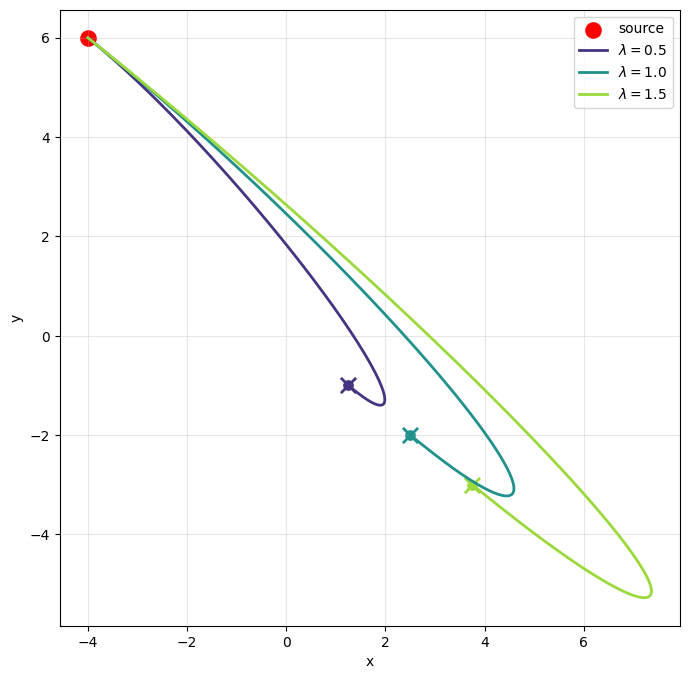

In [77]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


def langevin_backward_trajectory(source_point, target_point, steps=300, dt=0.02):
    """Return the full backward Langevin trajectory for one source point."""
    target_point = jnp.asarray(target_point)
    target_cloud = target_point[None, :]

    def step_fn(y, k):
        s = k / steps
        denom = 1 - s**2
        diff = y - s * target_cloud
        w = jnp.exp(-jnp.sum(diff**2, axis=-1) / (2 * denom))
        w = w / jnp.sum(w)
        dy = jnp.sum(w[:, None] * (target_cloud - s * y), axis=0) / denom
        y_next = y + dt * dy
        return y_next, y_next

    _, trajectory = jax.lax.scan(step_fn, jnp.asarray(source_point), jnp.arange(steps))
    return jnp.vstack([jnp.asarray(source_point)[None, :], trajectory])


source = jnp.array([-4.0, 6.0])
base_target = jnp.array([2.5, -2])
lambdas = [0.5, 1.0, 1.5]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(lambdas)))

plt.figure(figsize=(8, 8))
plt.scatter(source[0], source[1], c="red", s=120, marker="o", label="source")

for lam, color in zip(lambdas, colors):
    scaled_target = base_target * lam
    trajectory = np.array(langevin_backward_trajectory(source, scaled_target, steps=350, dt=0.025))

    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        color=color,
        lw=2,
        label=fr"$\lambda={lam}$",
    )
    plt.scatter(trajectory[-1, 0], trajectory[-1, 1], color=color, s=45)
    plt.scatter(
        scaled_target[0],
        scaled_target[1],
        color=color,
        marker="x",
        s=120,
        linewidths=2,
    )

# plt.title("Backward Langevin trajectory for one source and lambda-scaled target")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## The adversarial algorithm

### First approach: Gradient Descent

The objective is to find the maximal difference of the $L^2$ error of the Kim-Milman map and Semi-discrete optimal transport map

$$
\sup_{\rho \in \mathrm{supp}(\rho) \subset B_1} \int |T_{KM}(x) - T_{OT}(x)|^2 d\rho(x)
$$

In [78]:
def solve_semi_discrete_ot(xs, targets):
    geom = sdpc.SemidiscretePointCloud(
        sampler=jr.normal,
        y=targets,
        epsilon=0.01,
        cost_fn=costs.SqEuclidean(),
    )
    prob = sdlp.SemidiscreteLinearProblem(geom, b=jnp.ones(targets.shape[0]) / targets.shape[0])
    solver = semidiscrete.SemidiscreteSolver(
        num_iterations=3000,
        batch_size=1024,
        optimizer=optax.adam(learning_rate=0.1),
        error_eval_every=200,
        threshold=1e-3,
    )
    out = solver(rng_solve, prob)
    sampled_out = sd_out.sample(rng_sample_out, N_samples)

    return sampled_out.paired_indices[1], sampled_out.geom.x

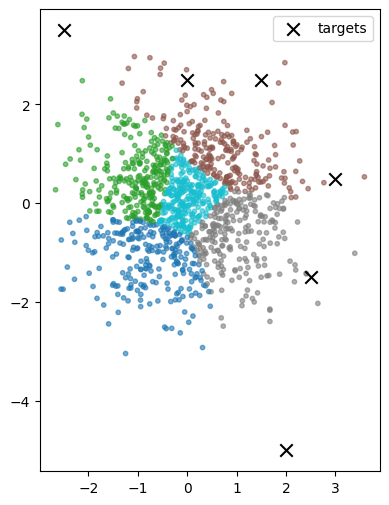

In [79]:
#example usage of the solve_semi_discrete_ot function
targets = jnp.array([[0.0, 2.5], [3.0, 0.5], [1.5, 2.5], [2.0, -5.0], [-2.5, 3.5], [2.5, -1.5]], dtype=jnp.float32)
assign_ot, T_ot = solve_semi_discrete_ot(x, targets)

#visualize the OT assignment
fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(6)
ax.scatter(x[:, 0], x[:, 1], c=assign_ot, s=10, alpha=0.6, cmap="tab10")
ax.scatter(targets[:, 0], targets[:, 1], c="black", s=80, marker="x", label="targets")
ax.set_aspect("equal", "box")
_ = ax.legend()


In [80]:
#randomize the targets and see how the OT assignment changes
rng_targets = jr.key(123)
random_targets = jax.random.permutation(rng_targets, targets, axis=0)
random_targets 

Array([[ 3. ,  0.5],
       [ 0. ,  2.5],
       [ 1.5,  2.5],
       [ 2. , -5. ],
       [-2.5,  3.5],
       [ 2.5, -1.5]], dtype=float32)